# 02 — Preprocessing & Baseline CNN
**MSB7216: Deep Learning for Health Data | Retinal Disease Classification**

This notebook covers:
1. Environment setup
2. Preprocessing pipeline (green channel + CLAHE + resize + normalise)
3. Dataset class and stratified train/val/test split
4. Data loaders with augmentation
5. Baseline CNN; architecture, training, evaluation
6. Save baseline results and figures
7. Commit and push

> **Purpose of the baseline:** establish the performance floor achievable *without* transfer learning.
> Every subsequent model must beat this to justify its added complexity.

---
## 0. Environment Setup

In [3]:
!pip install -q torch torchvision opencv-python-headless matplotlib seaborn pandas numpy Pillow tqdm scikit-learn

In [4]:
# SSH + clone
import os
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()  # upload retinal_deploy_key

!mv retinal_deploy_key /root/.ssh/retinal_deploy_key
!chmod 600 /root/.ssh/retinal_deploy_key

ssh_config = """
Host github-retinal
    HostName github.com
    User git
    IdentityFile /root/.ssh/retinal_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'retinal-disease-classification'
if not os.path.exists(REPO_NAME):
    !git clone git@github-retinal:Jeremy-K-coder/retinal-disease-classification.git

%cd {REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Ready.')

Saving retinal_deploy_key to retinal_deploy_key
Cloning into 'retinal-disease-classification'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 23 (delta 5), reused 17 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 10.33 MiB | 10.09 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/retinal-disease-classification
Already up to date.
Ready.


In [5]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Imports
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import random, shutil, json, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


In [23]:
# Paths
DATA_ROOT  = Path('/content/drive/MyDrive/retinal-disease-classification/data/raw')
MODELS_DIR = Path('/content/drive/MyDrive/retinal-disease-classification/models')
FIGURES    = Path('figures')
TRAIN_CURVES = Path(FIGURES / 'training_curves')

# Create directories if they don't exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
TRAIN_CURVES.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'Diabetic Retinopathy',
    'Glaucoma',
    'Disc Edema',
    'Macular Scar',
    'Myopia',
    'Retinal Detachment',
    'Retinitis Pigmentosa',
    'Pterygium',
    'Central Serous Chorioretinopathy',
    'Healthy',
]
NUM_CLASSES = len(CLASS_NAMES)

# Map folder names to class indices
# Update keys to match your actual folder names if they differ
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print('Class mapping:')
for k, v in CLASS_TO_IDX.items():
    print(f'  {v}: {k}')

Class mapping:
  0: Diabetic Retinopathy
  1: Glaucoma
  2: Disc Edema
  3: Macular Scar
  4: Myopia
  5: Retinal Detachment
  6: Retinitis Pigmentosa
  7: Pterygium
  8: Central Serous Chorioretinopathy
  9: Healthy


---
## 1. Preprocessing Pipeline

In [8]:
# Core preprocessing function
# Applied identically to every image before it enters any model.
# Steps are ordered deliberately:
#   1. Extract green channel  — maximises vessel/lesion contrast (justified in EDA)
#   2. CLAHE                  — local contrast enhancement without noise amplification
#   3. Convert to 3-channel   — pretrained models expect 3-channel input
#   4. Resize to 224x224      — standard for ImageNet pretrained architectures

def preprocess_fundus(img_path: str, img_size: int = 224) -> np.ndarray:
    """
    Load a fundus image and apply the full preprocessing pipeline.
    Returns a uint8 RGB numpy array of shape (img_size, img_size, 3).
    """
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f'Could not read image: {img_path}')

    # Step 1: Extract green channel
    _, green, _ = cv2.split(img)

    # Step 2: CLAHE on green channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    green_clahe = clahe.apply(green)

    # Step 3: Stack to 3-channel (required by pretrained models)
    img_3ch = cv2.merge([green_clahe, green_clahe, green_clahe])

    # Step 4: Resize
    img_resized = cv2.resize(img_3ch, (img_size, img_size),
                              interpolation=cv2.INTER_LINEAR)
    return img_resized  # uint8, shape (224, 224, 3)


print('preprocess_fundus() defined.')

preprocess_fundus() defined.


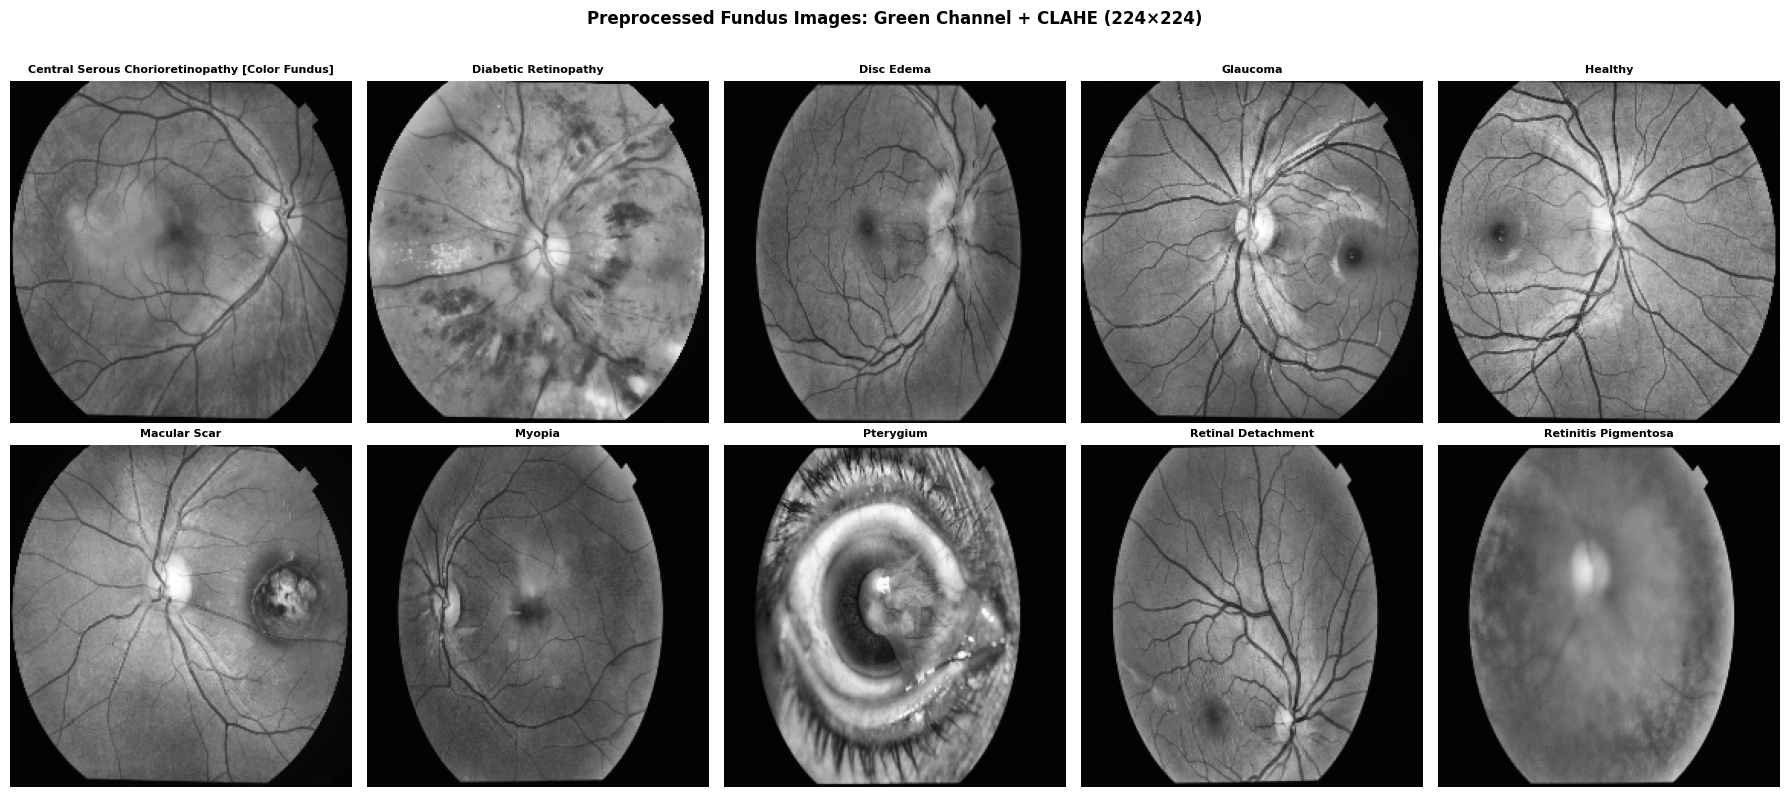

Saved → figures/preprocessed_sample_grid.png


In [11]:
# Visualise preprocessing on one image per class
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, class_dir in enumerate(sorted(DATA_ROOT.iterdir())):
    if not class_dir.is_dir() or idx >= NUM_CLASSES:
        continue
    imgs = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
    if not imgs:
        continue
    processed = preprocess_fundus(imgs[0])
    axes[idx].imshow(processed, cmap='gray')
    axes[idx].set_title(class_dir.name, fontsize=8, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle(
    'Preprocessed Fundus Images: Green Channel + CLAHE (224×224)',
    fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES / 'preprocessed_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/preprocessed_sample_grid.png')

---
## 2. Dataset Class & Stratified Split

In [12]:
# Collect all image paths and labels
all_paths, all_labels = [], []

for class_dir in sorted(DATA_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue
    # Match folder name to class index (update if folder names differ)
    matched = [name for name in CLASS_NAMES if name.lower() in class_dir.name.lower()]
    if not matched:
        print(f'WARNING: No class match for folder "{class_dir.name}" — skipping')
        continue
    label = CLASS_TO_IDX[matched[0]]
    imgs = list(class_dir.glob('*.jpg')) + \
           list(class_dir.glob('*.jpeg')) + \
           list(class_dir.glob('*.png'))
    all_paths.extend(imgs)
    all_labels.extend([label] * len(imgs))

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f'Total images collected: {len(all_paths)}')
print(f'Label range: {all_labels.min()} – {all_labels.max()}')

Total images collected: 5339
Label range: 0 – 9


In [13]:
# Stratified split: 70% train / 15% val / 15% test
# Stratified ensures every class is proportionally represented in all three splits.
# This is critical given the class imbalance identified in EDA.

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print(f'Train : {len(train_paths)} images')
print(f'Val   : {len(val_paths)} images')
print(f'Test  : {len(test_paths)} images')
print(f'Total : {len(train_paths) + len(val_paths) + len(test_paths)}')

# Save split indices for reproducibility across all notebooks
split_record = {
    'seed': SEED,
    'train': [str(p) for p in train_paths],
    'val':   [str(p) for p in val_paths],
    'test':  [str(p) for p in test_paths],
    'train_labels': train_labels.tolist(),
    'val_labels':   val_labels.tolist(),
    'test_labels':  test_labels.tolist(),
}
split_path = MODELS_DIR / 'data_split.json'
with open(split_path, 'w') as f:
    json.dump(split_record, f)
print(f'\nSplit saved → {split_path}')
print('All subsequent notebooks load this file to guarantee identical splits.')

Train : 3737 images
Val   : 801 images
Test  : 801 images
Total : 5339

Split saved → /content/drive/MyDrive/retinal-disease-classification/models/data_split.json
All subsequent notebooks load this file to guarantee identical splits.


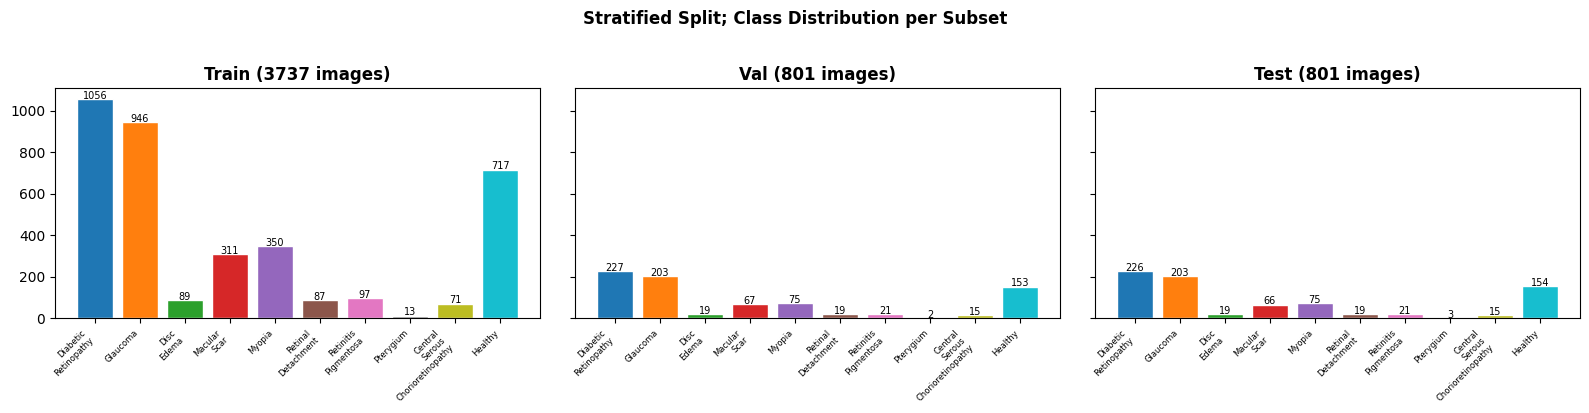

Saved → figures/stratified_split_verification.png


In [14]:
# Verify stratification
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
splits = [
    ('Train', train_labels),
    ('Val',   val_labels),
    ('Test',  test_labels),
]
palette = sns.color_palette('tab10', NUM_CLASSES)

for ax, (split_name, labels) in zip(axes, splits):
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    bars = ax.bar(range(NUM_CLASSES), counts, color=palette, edgecolor='white')
    ax.set_title(f'{split_name} ({len(labels)} images)', fontweight='bold')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(
        [c.replace(' ', '\n') for c in CLASS_NAMES],
        fontsize=6, rotation=45, ha='right'
    )
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(count), ha='center', fontsize=7
        )

plt.suptitle('Stratified Split; Class Distribution per Subset',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'stratified_split_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/stratified_split_verification.png')

---
## 3. PyTorch Dataset & DataLoaders

In [15]:
# Dataset class
# ImageNet normalisation constants — required for pretrained model compatibility
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class RetinalDataset(Dataset):
    """
    PyTorch Dataset for retinal fundus images.
    Applies preprocess_fundus() then the given torchvision transform.
    """
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = preprocess_fundus(self.paths[idx])   # (224, 224, 3) uint8
        img = Image.fromarray(img)                  # PIL for torchvision
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


# Transforms
# Training: light augmentation to improve generalisation without distorting
# retinal anatomy (no extreme flips or colour jitter, fundus images are
# already standardised in clinical photography)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation and test: no augmentation (deterministic evaluation)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Dataset class and transforms defined.')

Dataset class and transforms defined.


In [16]:
# DataLoaders
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_dataset = RetinalDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = RetinalDataset(val_paths,   val_labels,   transform=eval_transform)
test_dataset  = RetinalDataset(test_paths,  test_labels,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Verify a batch loads without error
imgs, labels = next(iter(train_loader))
print(f'\nBatch shape  : {imgs.shape}')   # expect (32, 3, 224, 224)
print(f'Labels shape : {labels.shape}')   # expect (32,)
print(f'Label range  : {labels.min().item()} – {labels.max().item()}')

Train batches : 117
Val batches   : 26
Test batches  : 26

Batch shape  : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Label range  : 0 – 9


In [17]:
# Compute class weights for weighted cross-entropy
# Inverse frequency weighting: rare classes get higher loss weight
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalise
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights (higher = rarer class):')
for name, w in zip(CLASS_NAMES, class_weights):
    print(f'  {name:<35} {w:.4f}')

Class weights (higher = rarer class):
  Diabetic Retinopathy                0.0709
  Glaucoma                            0.0792
  Disc Edema                          0.8415
  Macular Scar                        0.2408
  Myopia                              0.2140
  Retinal Detachment                  0.8609
  Retinitis Pigmentosa                0.7721
  Pterygium                           5.7612
  Central Serous Chorioretinopathy    1.0549
  Healthy                             0.1045


---
## 4. Baseline CNN

In [18]:
# Baseline architecture
# A simple 4-block CNN trained from scratch.
# Purpose: establish a performance floor WITHOUT transfer learning.
# Design is intentionally modest — this is a baseline, not a competitor.

class BaselineCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),          # → 112x112
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),          # → 56x56
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),          # → 28x28
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256),
            nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((4, 4)) # → 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in baseline_model.parameters())
print(f'Baseline CNN parameters: {total_params:,}')

Baseline CNN parameters: 2,492,170


In [19]:
# Training utilities
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, macro_f1, all_preds, all_labels


def plot_training_curves(history: dict, title: str, save_path: Path):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    metrics = [
        ('train_loss', 'val_loss',     'Loss',     'Loss'),
        ('train_acc',  'val_acc',      'Accuracy', 'Accuracy'),
        ('val_f1',     None,           'Val Macro F1', 'F1'),
    ]
    for ax, (train_key, val_key, title_str, ylabel) in zip(axes, metrics):
        epochs = range(1, len(history[train_key]) + 1)
        ax.plot(epochs, history[train_key], label='Train', color='steelblue', linewidth=2)
        if val_key and val_key in history:
            ax.plot(epochs, history[val_key], label='Val', color='darkorange',
                    linewidth=2, linestyle='--')
        ax.set_title(title_str, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
    plt.suptitle(title, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


print('Training utilities defined.')

Training utilities defined.


In [20]:
# Train baseline CNN
BASELINE_EPOCHS = 20
BASELINE_LR     = 1e-3

criterion_baseline = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=BASELINE_LR)
scheduler_baseline = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_baseline, T_max=BASELINE_EPOCHS
)

history_baseline = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc': [],
    'val_f1':     []
}
best_val_f1   = 0.0
CKPT_BASELINE = MODELS_DIR / 'baseline_cnn_best.pth'

print(f'Training Baseline CNN for {BASELINE_EPOCHS} epochs on {DEVICE}...')
print('-' * 55)

for epoch in range(1, BASELINE_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        baseline_model, train_loader, criterion_baseline,
        optimizer_baseline, DEVICE
    )
    val_loss, val_acc, val_f1, _, _ = evaluate(
        baseline_model, val_loader, criterion_baseline, DEVICE
    )
    scheduler_baseline.step()

    history_baseline['train_loss'].append(train_loss)
    history_baseline['val_loss'].append(val_loss)
    history_baseline['train_acc'].append(train_acc)
    history_baseline['val_acc'].append(val_acc)
    history_baseline['val_f1'].append(val_f1)

    # Save best checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     baseline_model.state_dict(),
            'optimizer_state_dict': optimizer_baseline.state_dict(),
            'val_f1':               val_f1,
            'val_acc':              val_acc,
        }, CKPT_BASELINE)
        flag = ' ← best'
    else:
        flag = ''

    print(
        f'Epoch {epoch:02d}/{BASELINE_EPOCHS} | '
        f'Loss {train_loss:.4f}/{val_loss:.4f} | '
        f'Acc {train_acc:.3f}/{val_acc:.3f} | '
        f'F1 {val_f1:.3f}{flag}'
    )

print(f'\nBest val F1: {best_val_f1:.4f}')
print(f'Checkpoint  : {CKPT_BASELINE}')

Training Baseline CNN for 20 epochs on cuda...
-------------------------------------------------------


Epoch 01/20 | Loss 2.3659/2.0306 | Acc 0.157/0.221 | F1 0.222 ← best


Epoch 02/20 | Loss 1.9947/1.8837 | Acc 0.171/0.174 | F1 0.184


Epoch 03/20 | Loss 1.8965/1.9891 | Acc 0.191/0.110 | F1 0.103


Epoch 04/20 | Loss 1.8581/1.8561 | Acc 0.232/0.267 | F1 0.251 ← best


...

Epoch 16/20 | Loss 1.5169/1.5180 | Acc 0.345/0.367 | F1 0.371 ← best


Epoch 17/20 | Loss 1.4978/1.5525 | Acc 0.330/0.348 | F1 0.365


Epoch 18/20 | Loss 1.4894/1.5189 | Acc 0.336/0.378 | F1 0.366


Epoch 19/20 | Loss 1.4831/1.5018 | Acc 0.359/0.386 | F1 0.393 ← best


Epoch 20/20 | Loss 1.4855/1.5034 | Acc 0.356/0.382 | F1 0.387

Best val F1: 0.3926
Checkpoint  : /content/drive/MyDrive/retinal-disease-classification/models/baseline_cnn_best.pth


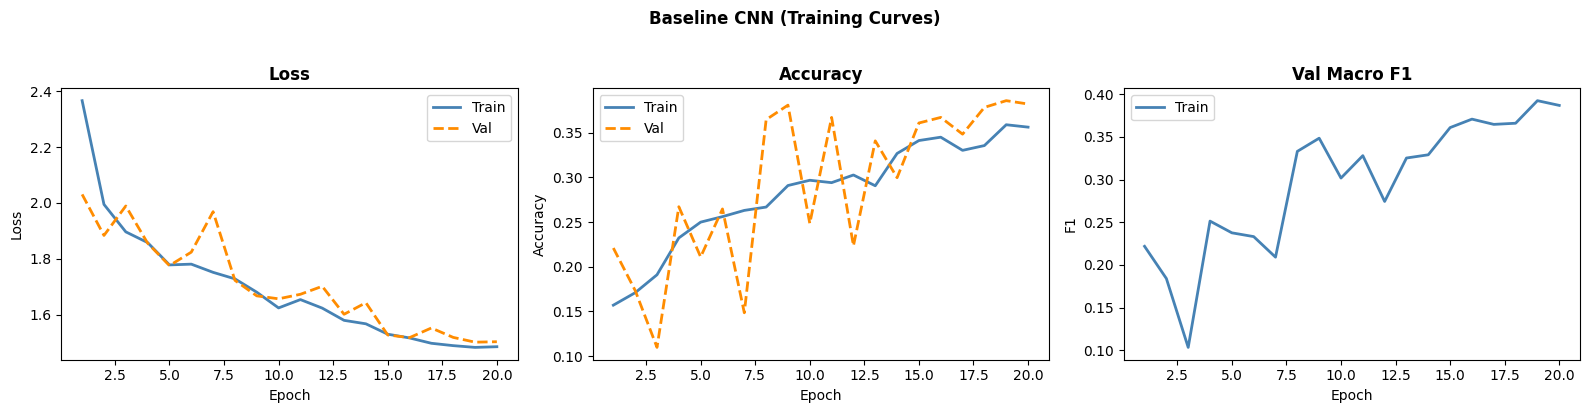

Saved → figures/training_curves/baseline_cnn.png


In [24]:
# Training curves
plot_training_curves(
    history_baseline,
    title='Baseline CNN (Training Curves)',
    save_path=TRAIN_CURVES/ 'baseline_cnn.png'
)

---
## 5. Baseline Evaluation on Test Set

In [25]:
# Load best checkpoint and evaluate on held-out test set
checkpoint = torch.load(CKPT_BASELINE, map_location=DEVICE)
baseline_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} "
      f"(val F1 = {checkpoint['val_f1']:.4f})")

_, test_acc, test_f1, test_preds, test_labels_list = evaluate(
    baseline_model, test_loader, criterion_baseline, DEVICE
)
print(f'\nTest Accuracy : {test_acc:.4f}')
print(f'Test Macro F1 : {test_f1:.4f}')

Loaded best checkpoint from epoch 19 (val F1 = 0.3926)



Test Accuracy : 0.3883
Test Macro F1 : 0.4090


In [26]:
# Per-class report
print('Classification Report (Baseline CNN):')
print(classification_report(
    test_labels_list, test_preds,
    target_names=CLASS_NAMES, zero_division=0
))

Classification Report (Baseline CNN):
                                  precision    recall  f1-score   support

            Diabetic Retinopathy       0.74      0.45      0.56       226
                        Glaucoma       0.50      0.23      0.31       203
                      Disc Edema       0.11      0.58      0.19        19
                    Macular Scar       0.20      0.18      0.19        66
                          Myopia       0.38      0.37      0.38        75
              Retinal Detachment       0.42      0.84      0.56        19
            Retinitis Pigmentosa       0.22      0.76      0.34        21
                       Pterygium       1.00      1.00      1.00         3
Central Serous Chorioretinopathy       0.04      0.20      0.06        15
                         Healthy       0.49      0.48      0.49       154

                        accuracy                           0.39       801
                       macro avg       0.41      0.51      0.41       80

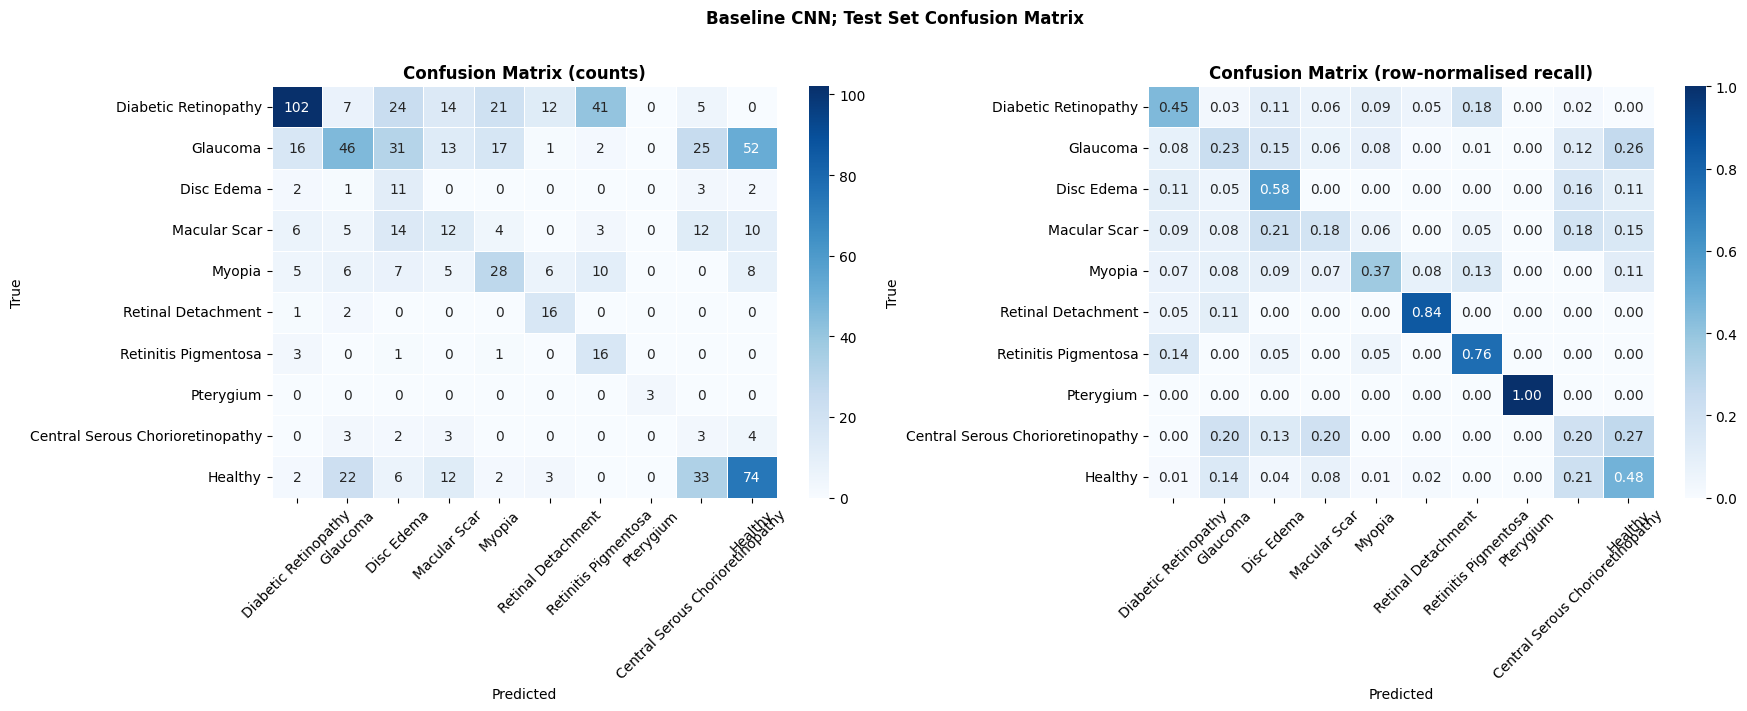

Saved → figures/confusion_matrix_baseline.png


In [27]:
# Confusion matrix
cm = confusion_matrix(test_labels_list, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Row-normalised (recall per class)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title('Confusion Matrix (row-normalised recall)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Baseline CNN; Test Set Confusion Matrix', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/confusion_matrix_baseline.png')

In [28]:
# Save baseline results for comparison with EfficientNet and ConvNeXt
baseline_results = {
    'model':        'Baseline CNN',
    'loss':         'Weighted Cross-Entropy',
    'test_acc':     round(test_acc, 4),
    'test_macro_f1': round(test_f1, 4),
    'clinical_cost': None,   # To be computed later
    'confusion_matrix': cm.tolist(),
}
results_path = MODELS_DIR / 'results_baseline.json'
with open(results_path, 'w') as f:
    json.dump(baseline_results, f, indent=2)
print(f'Results saved → {results_path}')
print()
print('BASELINE SUMMARY')
print(f'  Accuracy : {test_acc:.4f}')
print(f'  Macro F1 : {test_f1:.4f}')
print()
print('This is the floor. EfficientNet and ConvNeXt must beat both metrics.')

Results saved → /content/drive/MyDrive/retinal-disease-classification/models/results_baseline.json

BASELINE SUMMARY
  Accuracy : 0.3883
  Macro F1 : 0.4090

This is the floor. EfficientNet and ConvNeXt must beat both metrics.


---
## 6. Commit and Push

In [ ]:
# Push notebook and figures to GitHub

NB_SRC  = Path('/content/drive/MyDrive/Colab Notebooks/02_Preprocessing_Baseline.ipynb')
NB_DEST = Path('/content/retinal-disease-classification/notebooks/02_Preprocessing_Baseline.ipynb')
NB_DEST.parent.mkdir(parents=True, exist_ok=True)
if NB_SRC.exists():
    shutil.copy(NB_SRC, NB_DEST)
    print(f'Copied notebook → {NB_DEST}')

!git add /content/retinal-disease-classification/notebooks/02_Preprocessing_Baseline.ipynb figures/
!git status
!git commit -m "Preprocessing pipeline, stratified split, baseline CNN training and evaluation"
!git push
print('Done — Notebook 02 committed and pushed.')